# Credit Card Default — Logistic Regression

This notebook trains a **Logistic Regression** model to predict whether a credit card client
will default on their next payment.

Workflow:
1. Load and inspect the dataset
2. Analyse the target distribution (class imbalance)
3. One-hot encode the categorical variables (Sex, Education, Marital status)
4. Stratified train / test split (80 / 20)
5. Feature engineering (utilisation, payment ratio, payment volatility) — performed *inside* the pipeline so there is no leakage from the test set
6. Pipeline: feature engineering → scaling (only numeric columns) → Logistic Regression
7. Hyper-parameter tuning with `GridSearchCV` (Elastic-Net penalty)
8. Evaluation on the test set (ROC-AUC)
9. Predict the probability of default for a single custom input

## 1. Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys
!{sys.executable} -m pip install xlrd

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import RobustScaler, FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    classification_report,
)

# Reproducibility
RANDOM_STATE = 42

pd.set_option("display.max_columns", 50)

## 2. Load the Dataset

The UCI "default of credit card clients" dataset is provided as an `.xls` file.
The header sits on the *second* row (the first row contains column codes like X1, X2, ...),
so we pass `header=1` to `read_excel`.

> Note: to read `.xls` you need `xlrd==1.2.0` (`pip install xlrd==1.2.0`).
> If you convert the file to `.xlsx` first, `openpyxl` works out of the box.

In [2]:
DATA_PATH = "default of credit card clients.xls"

df = pd.read_excel(DATA_PATH, header=1, engine="xlrd")

# Drop the ID column — it carries no information
df = df.drop(columns=["ID"])

# Rename the target column for convenience
df = df.rename(columns={"default payment next month": "default"})

print("Shape:", df.shape)
df.head()

Shape: (30000, 24)


,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default
0,20000,2,2,1,24,2,2,-1,-1,-2,-2,3913,3102,689,0,0,0,0,689,0,0,0,0,1
1,120000,2,2,2,26,-1,2,0,0,0,2,2682,1725,2682,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,90000,2,2,2,34,0,0,0,0,0,0,29239,14027,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,50000,2,2,1,37,0,0,0,0,0,0,46990,48233,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,50000,1,2,1,57,-1,0,-1,0,0,0,8617,5670,35835,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 24 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   LIMIT_BAL  30000 non-null  int64
 1   SEX        30000 non-null  int64
 2   EDUCATION  30000 non-null  int64
 3   MARRIAGE   30000 non-null  int64
 4   AGE        30000 non-null  int64
 5   PAY_0      30000 non-null  int64
 6   PAY_2      30000 non-null  int64
 7   PAY_3      30000 non-null  int64
 8   PAY_4      30000 non-null  int64
 9   PAY_5      30000 non-null  int64
 10  PAY_6      30000 non-null  int64
 11  BILL_AMT1  30000 non-null  int64
 12  BILL_AMT2  30000 non-null  int64
 13  BILL_AMT3  30000 non-null  int64
 14  BILL_AMT4  30000 non-null  int64
 15  BILL_AMT5  30000 non-null  int64
 16  BILL_AMT6  30000 non-null  int64
 17  PAY_AMT1   30000 non-null  int64
 18  PAY_AMT2   30000 non-null  int64
 19  PAY_AMT3   30000 non-null  int64
 20  PAY_AMT4   30000 non-null  int64
 21  PAY_AMT5   3

In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
LIMIT_BAL,30000.0,167484.322667,129747.661567,10000.0,50000.00,140000.0,240000.00,1000000.0
SEX,30000.0,1.603733,0.489129,1.0,1.00,2.0,2.00,2.0
EDUCATION,30000.0,1.853133,0.790349,0.0,1.00,2.0,2.00,6.0
MARRIAGE,30000.0,1.551867,0.521970,0.0,1.00,2.0,2.00,3.0
AGE,30000.0,35.485500,9.217904,21.0,28.00,34.0,41.00,79.0
PAY_0,30000.0,-0.016700,1.123802,-2.0,-1.00,0.0,0.00,8.0
PAY_2,30000.0,-0.133767,1.197186,-2.0,-1.00,0.0,0.00,8.0
PAY_3,30000.0,-0.166200,1.196868,-2.0,-1.00,0.0,0.00,8.0
PAY_4,30000.0,-0.220667,1.169139,-2.0,-1.00,0.0,0.00,8.0
PAY_5,30000.0,-0.266200,1.133187,-2.0,-1.00,0.0,0.00,8.0


## 3. Target Distribution (Class Imbalance)

We check the share of defaulting vs. non-defaulting clients.
If one class dominates, plain accuracy is a poor metric — that is why we will use **ROC-AUC**
and set `class_weight="balanced"` in the Logistic Regression.

Counts:
default
0    23364
1     6636
Name: count, dtype: int64

Share:
default
0    0.7788
1    0.2212
Name: proportion, dtype: float64


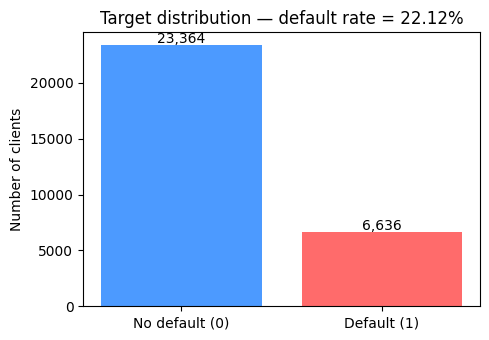

In [5]:
target_counts = df["default"].value_counts()
target_share = df["default"].value_counts(normalize=True).round(4)

print("Counts:")
print(target_counts)
print("\nShare:")
print(target_share)

fig, ax = plt.subplots(figsize=(5, 3.5))
ax.bar(["No default (0)", "Default (1)"], target_counts.values,
       color=["#4C9AFF", "#FF6B6B"])
ax.set_ylabel("Number of clients")
ax.set_title(f"Target distribution — default rate = {target_share[1]:.2%}")
for i, v in enumerate(target_counts.values):
    ax.text(i, v + 200, f"{v:,}", ha="center")
plt.tight_layout()
plt.show()

## 4. One-Hot Encoding of the Categorical Variables

The three nominal variables need one-hot encoding:

| Column       | Meaning                                                 |
| ------------ | ------------------------------------------------------- |
| `SEX`        | 1 = male, 2 = female                                    |
| `EDUCATION`  | 1 = graduate, 2 = university, 3 = high school, 4 = others |
| `MARRIAGE`   | 1 = married, 2 = single, 3 = others                     |

We use `drop_first=True` to avoid multicollinearity (one reference category per variable).

> Note on `PAY_0 … PAY_6`: these "repayment status" columns are ordinal (−1 = pay duly, 1 = one
> month delay, ...). We keep them as numeric values, which is the standard choice for this dataset.

In [6]:
CATEGORICAL_COLS = ["SEX", "EDUCATION", "MARRIAGE"]

df_encoded = pd.get_dummies(
    df,
    columns=CATEGORICAL_COLS,
    drop_first=True,   # drop the first level to avoid multicollinearity
    dtype=int,
)

print("Shape after one-hot encoding:", df_encoded.shape)
df_encoded.head()

Shape after one-hot encoding: (30000, 31)


,LIMIT_BAL,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default,SEX_2,EDUCATION_1,EDUCATION_2,EDUCATION_3,EDUCATION_4,EDUCATION_5,EDUCATION_6,MARRIAGE_1,MARRIAGE_2,MARRIAGE_3
0,20000,24,2,2,-1,-1,-2,-2,3913,3102,689,0,0,0,0,689,0,0,0,0,1,1,0,1,0,0,0,0,1,0,0
1,120000,26,-1,2,0,0,0,2,2682,1725,2682,3272,3455,3261,0,1000,1000,1000,0,2000,1,1,0,1,0,0,0,0,0,1,0
2,90000,34,0,0,0,0,0,0,29239,14027,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000,0,1,0,1,0,0,0,0,0,1,0
3,50000,37,0,0,0,0,0,0,46990,48233,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000,0,1,0,1,0,0,0,0,1,0,0
4,50000,57,-1,0,-1,0,0,0,8617,5670,35835,20940,19146,19131,2000,36681,10000,9000,689,679,0,0,0,1,0,0,0,0,1,0,0


## 5. Train / Test Split (Stratified, 80 / 20)

`stratify=y` guarantees that the class balance (~22 % defaults) is preserved in both splits.

In [7]:
X = df_encoded.drop(columns=["default"])
y = df_encoded["default"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE,
)

print("Train shape:", X_train.shape, " default rate:", y_train.mean().round(4))
print("Test  shape:", X_test.shape,  " default rate:", y_test.mean().round(4))

Train shape: (24000, 30)  default rate: 0.2212
Test  shape: (6000, 30)  default rate: 0.2212


## 6. Feature Engineering (inside the pipeline)

We add four new features, all computed **per row**:

| Feature             | Definition                                                       |
| ------------------- | ---------------------------------------------------------------- |
| `util_mean`         | mean(`BILL_AMT1` … `BILL_AMT6`) / `LIMIT_BAL`                    |
| `util_last`         | `BILL_AMT6` / `LIMIT_BAL`                                        |
| `pay_ratio_last`    | `PAY_AMT6` / `BILL_AMT6` **if** `BILL_AMT6 > 0`, else 0          |
| `pay_amt_std`       | Standard deviation of `PAY_AMT1 … PAY_AMT6` (payment volatility) |

Wrapping this into a `FunctionTransformer` and placing it inside the pipeline keeps the train
and test transformations completely independent — **no leakage**. Because each feature is
derived row-wise (it does not depend on statistics computed over the whole dataset) the
transformer is `stateless` and safe to apply to new data.

In [8]:

BILL_COLS = [f"BILL_AMT{i}" for i in range(1, 7)]
PAY_AMT_COLS = [f"PAY_AMT{i}" for i in range(1, 7)]

def add_engineered_features(X: pd.DataFrame) -> pd.DataFrame:
    """Row-wise feature engineering. Stateless, so no leakage between splits."""
    X = X.copy()

    # Utilisation ratios (credit used relative to credit limit)
    X["util_mean"] = X[BILL_COLS].mean(axis=1) / X["LIMIT_BAL"]
    X["util_last"] = X["BILL_AMT1"] / X["LIMIT_BAL"]

    # Payment ratio for the last month; guard against division by zero
    bill = X["BILL_AMT1"]   # oder BILL_AMT6, wenn du beim alten bleibst
    pay  = X["PAY_AMT1"]
    X["pay_ratio_last"] = np.where(
        bill > 0,
        pay / bill,
        0.0
    )
    X["no_bill_last"] = (bill <= 0).astype(int)

    # Volatility of monthly payments
    X["pay_amt_std"] = X[PAY_AMT_COLS].std(axis=1).fillna(0.0)

    return X

ENGINEERED_COLS = ["util_mean", "util_last", "pay_ratio_last", "no_bill_last", "pay_amt_std"]

class EngineeringTransformer(FunctionTransformer):
    """Custom FunctionTransformer with proper feature_names_out."""
    
    def fit(self, X, y=None, **fit_params):
        # Store the feature names during fit
        if hasattr(X, 'columns'):
            self.feature_names_in_ = X.columns.tolist()
        else:
            self.feature_names_in_ = [f"x{i}" for i in range(X.shape[1])]
        
        # Call parent fit
        result = super().fit(X, y, **fit_params)
        
        # Set n_features_in_ based on the input
        self.n_features_in_ = X.shape[1]
        
        return result
    
    def get_feature_names_out(self, input_features=None):
        """Return all feature names after engineering."""
        if input_features is None:
            if hasattr(self, 'feature_names_in_'):
                feature_names = list(self.feature_names_in_)
            else:
                feature_names = [f"x{i}" for i in range(self.n_features_in_)]
        else:
            feature_names = list(input_features)
        
        return np.array(feature_names + ENGINEERED_COLS)

feature_engineer = EngineeringTransformer(
    add_engineered_features,
    validate=False,
)

# Quick sanity check on the training data
X_train_fe_preview = add_engineered_features(X_train.head())
X_train_fe_preview[["LIMIT_BAL", "BILL_AMT1", "PAY_AMT1",
                    "util_mean", "util_last", "pay_ratio_last", "no_bill_last", "pay_amt_std"]]

,LIMIT_BAL,BILL_AMT1,PAY_AMT1,util_mean,util_last,pay_ratio_last,no_bill_last,pay_amt_std
22788,160000,161771,15000,1.034312,1.011069,0.092724,0,6175.246284
29006,150000,0,53,0.000059,0.000000,0.000000,1,21.637159
16950,10000,10171,2,0.857683,1.017100,0.000197,0,532.604794
22280,220000,206879,9100,0.846647,0.940359,0.043987,0,1971.316354
11346,310000,0,0,0.000098,0.000000,0.000000,1,481.282315


## 7. Build the Pipeline

Pipeline steps:

1. **Feature engineering** (the `FunctionTransformer` above)
2. **Column transformer**
   * Numeric columns → `RobustScaler` (robust against outliers typical in financial data)
   * One-hot dummy columns → `passthrough` (they are already 0/1 and should not be scaled)
3. **Logistic Regression** with
   * `penalty="elasticnet"` (combines L1 and L2)
   * `solver="saga"` (the only solver that supports elastic-net)
   * `class_weight="balanced"` (adjusts for the imbalance)
   * `max_iter=1000`

In [9]:
# Columns that are *not* dummies — these should be scaled.
# Dummy columns are those produced by pd.get_dummies above.
DUMMY_COLS = [c for c in X_train.columns
              if c.startswith(("SEX_", "EDUCATION_", "MARRIAGE_"))]

# Numeric columns = everything that is not a dummy,
# PLUS the four features created by the FunctionTransformer.
ORIGINAL_NUMERIC_COLS = [c for c in X_train.columns if c not in DUMMY_COLS]
ENGINEERED_COLS = ["util_mean", "util_last", "pay_ratio_last", "pay_amt_std"]
NUMERIC_COLS = ORIGINAL_NUMERIC_COLS + ENGINEERED_COLS

preprocessor = ColumnTransformer(
    transformers=[
        ("num", RobustScaler(), NUMERIC_COLS),
        ("cat", "passthrough", DUMMY_COLS),
    ],
    remainder="drop",
)

logreg = LogisticRegression(
    penalty="elasticnet",
    solver="saga",
    class_weight="balanced",
    max_iter=1000,
    random_state=RANDOM_STATE,
)

pipeline = Pipeline(steps=[
    ("feature_engineering", feature_engineer),
    ("preprocessor", preprocessor),
    ("model", logreg),
])

pipeline

,steps,"[('feature_engineering', ...), ('preprocessor', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,func,<function add...t 0x12baf1c60>
,inverse_func,None
,validate,False
,accept_sparse,False
,check_inverse,True
,feature_names_out,None
,kw_args,None


## 8. Hyper-parameter Tuning with `GridSearchCV`

Search grid:

* `C` ∈ {0.001, 0.01, 0.1, 1, 10, 100}
* `l1_ratio` ∈ {0, 0.25, 0.5, 0.75}
* 5-fold stratified cross-validation
* Metric: **ROC-AUC** (appropriate under class imbalance)

> Note: `saga` is an iterative solver and elastic-net makes the search heavier.
> Expect the grid search to take a few minutes on the full training set.

In [10]:
param_grid = {
    "model__C":        [0.001, 0.01, 0.1, 1, 10, 100],
    "model__l1_ratio": [0.0, 0.25, 0.5, 0.75],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

grid = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    refit=True,
    verbose=1,
)

grid.fit(X_train, y_train)

print("Best parameters:", grid.best_params_)
print(f"Best CV ROC-AUC : {grid.best_score_:.4f}")

Fitting 5 folds for each of 24 candidates, totalling 120 fits


/opt/miniconda3/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/miniconda3/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/miniconda3/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/miniconda3/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/miniconda3/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/miniconda3/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: T

Best parameters: {'model__C': 0.001, 'model__l1_ratio': 0.75}
Best CV ROC-AUC : 0.7026


/opt/miniconda3/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


In [11]:
# Full CV results sorted by mean ROC-AUC
cv_results = (
    pd.DataFrame(grid.cv_results_)
      .loc[:, ["param_model__C", "param_model__l1_ratio",
               "mean_test_score", "std_test_score", "rank_test_score"]]
      .sort_values("rank_test_score")
      .reset_index(drop=True)
)
cv_results.head(10)

,param_model__C,param_model__l1_ratio,mean_test_score,std_test_score,rank_test_score
0,0.001,0.75,0.702582,0.008255,1
1,0.001,0.50,0.702194,0.008351,2
2,0.001,0.25,0.701868,0.008476,3
3,0.010,0.75,0.701770,0.008583,4
4,0.010,0.50,0.701753,0.008600,5
5,0.010,0.25,0.701745,0.008624,6
6,0.100,0.75,0.701743,0.008646,7
7,0.100,0.50,0.701742,0.008646,8
8,1.000,0.75,0.701740,0.008648,9
9,0.100,0.25,0.701740,0.008646,10


## 9. Evaluation on the Hold-Out Test Set

In [12]:
best_model = grid.best_estimator_

# Probabilities for the positive class (default = 1)
y_proba = best_model.predict_proba(X_test)[:, 1]
y_pred  = best_model.predict(X_test)

test_auc = roc_auc_score(y_test, y_proba)

print(f"Test ROC-AUC: {test_auc:.4f}")
print()
print("Classification report (threshold = 0.2):") # because the default rate is around 20% so this threshold is a natural choice to start with. Also we'd rather wrongly classify no default as default, because wrongly predicten default as no default is more costly.
print(classification_report(y_test, y_pred, digits=3))
print("Confusion matrix:")
print(confusion_matrix(y_test, y_pred))

Test ROC-AUC: 0.6893

Classification report (threshold = 0.2):
              precision    recall  f1-score   support

           0      0.848     0.748     0.795      4673
           1      0.372     0.526     0.436      1327

    accuracy                          0.699      6000
   macro avg      0.610     0.637     0.615      6000
weighted avg      0.742     0.699     0.715      6000

Confusion matrix:
[[3496 1177]
 [ 629  698]]


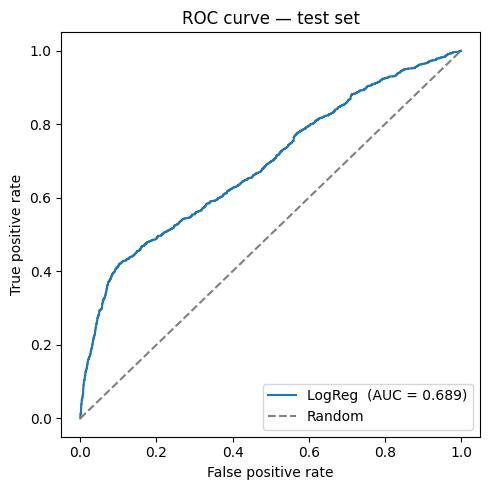

In [13]:
# ROC curve
fpr, tpr, _ = roc_curve(y_test, y_proba)

fig, ax = plt.subplots(figsize=(5, 5))
ax.plot(fpr, tpr, label=f"LogReg  (AUC = {test_auc:.3f})", color="#1f77b4")
ax.plot([0, 1], [0, 1], linestyle="--", color="grey", label="Random")
ax.set_xlabel("False positive rate")
ax.set_ylabel("True positive rate")
ax.set_title("ROC curve — test set")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

In [14]:
# print the coefficients of the best model
feature_names = best_model[:-1].get_feature_names_out()
coefficients = best_model.named_steps["model"].coef_[0]

coef_df = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coefficients
})

coef_df = coef_df.sort_values(by="coefficient", ascending=False)

print(coef_df.head(10))

ValueError: input_features is not equal to feature_names_in_

## 10. Predict the Probability of Default for a Single Client

Pass a dictionary with the **raw** input values (same columns as the original dataset — except
`ID` and `default`). The helper takes care of one-hot encoding and feature engineering
by re-using the fitted pipeline.

In [ ]:
# Columns of the one-hot-encoded feature matrix (= what the pipeline expects)
MODEL_COLUMNS = X.columns.tolist()

def predict_default_probability(raw_input: dict, model=best_model) -> float:
    """
    Convert a raw client record into the encoded feature vector the pipeline
    expects and return the probability of default.

    Required keys in ``raw_input`` (same as the original dataset):
        LIMIT_BAL, SEX, EDUCATION, MARRIAGE, AGE,
        PAY_0, PAY_2, PAY_3, PAY_4, PAY_5, PAY_6,
        BILL_AMT1..BILL_AMT6, PAY_AMT1..PAY_AMT6
    """
    # 1) Build a single-row DataFrame with the raw values
    raw_df = pd.DataFrame([raw_input])

    # 2) Apply the same one-hot encoding as during training
    raw_df = pd.get_dummies(
        raw_df,
        columns=CATEGORICAL_COLS,
        drop_first=True,
        dtype=int,
    )

    # 3) Make sure all model columns are present and in the correct order
    #    (missing dummy columns -> 0)
    raw_df = raw_df.reindex(columns=MODEL_COLUMNS, fill_value=0)

    # 4) Predict
    proba = model.predict_proba(raw_df)[0, 1]
    return float(proba)


# Example client
example_client = {
    "LIMIT_BAL": 50000,
    "SEX":       2,   # female
    "EDUCATION": 2,   # university
    "MARRIAGE":  1,   # married
    "AGE":       35,
    "PAY_0": 0, "PAY_2": 0, "PAY_3": 0, "PAY_4": 0, "PAY_5": 0, "PAY_6": 0,
    "BILL_AMT1": 20000, "BILL_AMT2": 19000, "BILL_AMT3": 18000,
    "BILL_AMT4": 17000, "BILL_AMT5": 16000, "BILL_AMT6": 15000,
    "PAY_AMT1": 2000,  "PAY_AMT2": 2000, "PAY_AMT3": 2000,
    "PAY_AMT4": 2000,  "PAY_AMT5": 2000, "PAY_AMT6": 2000,
}

p = predict_default_probability(example_client)
print(f"Predicted probability of default: {p:.4f}  ({p:.2%})")

Predicted probability of default: 0.5009  (50.09%)


### Summary

* The dataset is imbalanced (~22 % defaults) — we used `class_weight="balanced"` and **ROC-AUC** as the evaluation metric.
* Feature engineering is wrapped in a `FunctionTransformer` inside the pipeline, so training and test sets are transformed independently (no leakage).
* Only the numeric columns are scaled with `RobustScaler`; the one-hot dummies are passed through unchanged.
* The best hyper-parameters (`C`, `l1_ratio`) were selected via 5-fold stratified CV on the training set and evaluated once on the untouched test set.
* `predict_default_probability(...)` turns a raw client record into a default probability you can use for new predictions.

# Credit Card Default — XGBoost

In diesem zweiten Teil trainieren wir ein **XGBoost**-Modell (Gradient Boosted Trees) für
denselben Klassifikationsauftrag (Ausfall vs. kein Ausfall).

Wir nutzen die bereits oben erstellten Objekte weiter und müssen sie **nicht** neu berechnen:

* `df_encoded` — One-Hot-kodierter DataFrame
* `X_train`, `X_test`, `y_train`, `y_test` — stratifizierter 80/20-Split
* `add_engineered_features` und `feature_engineer` — zeilenweises Feature Engineering
  (identisch zur LogReg, damit beide Modelle auf denselben Features arbeiten)
* `CATEGORICAL_COLS`, `DUMMY_COLS`, `NUMERIC_COLS`, `MODEL_COLUMNS`

Wichtige Unterschiede zur Logistic Regression:

1. **Kein Scaling** — baumbasierte Modelle sind invariant gegenüber monotonen Transformationen
   der einzelnen Features, Scaling bringt also keinen Nutzen.
2. **`scale_pos_weight`** statt `class_weight="balanced"` — die native XGBoost-Art,
   mit Class Imbalance umzugehen. Wir setzen sie auf `#no_default / #default`.
3. **Early Stopping** — während des Trainings wird die Anzahl der Bäume automatisch
   begrenzt, sobald sich die Validation-AUC 50 Runden lang nicht mehr verbessert.
4. **RandomizedSearchCV** statt GridSearchCV — der Hyperparameter-Raum ist deutlich
   größer (8 Parameter × viele Werte), ein vollständiger Grid wäre zu teuer.
   Wir ziehen 75 zufällige Kombinationen.


## 11. XGBoost — Imports

In [15]:
# XGBoost wird ggf. installiert (falls es in der Umgebung noch nicht vorhanden ist)
import sys
!{sys.executable} -m pip install -q xgboost

# RandomizedSearchCV ergänzt das bereits importierte GridSearchCV
from sklearn.model_selection import RandomizedSearchCV

# XGBoost-Klassifikator (sklearn-kompatibles Interface)
from xgboost import XGBClassifier


## 12. `scale_pos_weight` berechnen

XGBoost gewichtet die positive Klasse intern mit `scale_pos_weight`.
Der empfohlene Wert bei Class Imbalance ist das Verhältnis

```
scale_pos_weight = Anzahl negativer Beispiele (kein Default)
                   --------------------------------------------
                   Anzahl positiver Beispiele (Default)
```

Wir berechnen das Verhältnis ausschließlich auf dem **Trainingsset**, um keine Information
aus dem Testset einzuschleppen.


In [16]:
# Anzahl pro Klasse im Trainingsset
n_neg = int((y_train == 0).sum())   # kein Default
n_pos = int((y_train == 1).sum())   # Default

# Verhältnis der negativen zur positiven Klasse
scale_pos_weight = n_neg / n_pos

print(f"# kein Default (y=0): {n_neg}")
print(f"# Default      (y=1): {n_pos}")
print(f"scale_pos_weight = {scale_pos_weight:.4f}")


# kein Default (y=0): 18691
# Default      (y=1): 5309
scale_pos_weight = 3.5206


## 13. Validation-Split für Early Stopping

Early Stopping benötigt ein separates Validation-Set, auf dem XGBoost nach jeder
Boosting-Runde die Metrik auswertet. Wir schneiden dafür einen kleinen, stratifizierten
Teil vom Trainingsset ab (10 %), so dass

* 90 % der Trainingsdaten → `X_tr`, `y_tr` (für das eigentliche Fitten / die CV)
* 10 % der Trainingsdaten → `X_val`, `y_val` (ausschließlich für Early Stopping)

Das Testset bleibt davon unberührt und wird erst ganz am Ende benutzt.

Da unser Feature Engineering zeilenweise und *stateless* ist, können wir es direkt auf
`X_val` anwenden, ohne Leakage zu riskieren. Der so vorbereitete `X_val_fe` wird als
`eval_set` an XGBoost übergeben.


In [17]:
# Stratifizierter Split innerhalb des Trainingssets: 10 % Validation für Early Stopping
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train,
    test_size=0.10,
    stratify=y_train,
    random_state=RANDOM_STATE,
)

# Feature Engineering ist stateless (zeilenweise), daher kein Leakage durch
# das Vorab-Anwenden auf die Validation-Daten
X_val_fe = add_engineered_features(X_val)

print("X_tr  shape:", X_tr.shape,  " Default-Anteil:", y_tr.mean().round(4))
print("X_val shape:", X_val.shape, " Default-Anteil:", y_val.mean().round(4))


X_tr  shape: (21600, 30)  Default-Anteil: 0.2212
X_val shape: (2400, 30)  Default-Anteil: 0.2212


## 14. Pipeline aufbauen (ohne Scaling)

Da XGBoost kein Scaling benötigt, enthält die Pipeline nur zwei Schritte:

1. **Feature Engineering** (`feature_engineer`, identisch zur LogReg)
2. **XGBoost-Modell** (`XGBClassifier`)

Fixe Parameter des Modells (werden nicht getuned):

| Parameter                  | Wert                 | Bedeutung                                                |
| -------------------------- | -------------------- | -------------------------------------------------------- |
| `objective`                | `"binary:logistic"`  | binäre Klassifikation                                    |
| `eval_metric`              | `"auc"`              | dieselbe Metrik wie bei der Tuning-Suche (ROC-AUC)       |
| `scale_pos_weight`         | `n_neg / n_pos`      | kompensiert die Class Imbalance                          |
| `early_stopping_rounds`    | `50`                 | stoppt, wenn sich die AUC 50 Runden nicht mehr bessert   |
| `n_estimators`             | `2000`               | Obergrenze — Early Stopping wählt die tatsächliche Zahl  |
| `tree_method`              | `"hist"`             | schnelle Histogramm-Implementierung                      |
| `random_state`             | `RANDOM_STATE`       | Reproduzierbarkeit                                       |


In [18]:
# XGBoost-Klassifikator mit fixen (nicht zu tunenden) Parametern
xgb = XGBClassifier(
    objective="binary:logistic",        # binäre Klassifikation
    eval_metric="auc",                  # ROC-AUC als Optimierungs-/Stop-Metrik
    scale_pos_weight=scale_pos_weight,  # kompensiert die Class Imbalance
    n_estimators=2000,                  # Obergrenze; Early Stopping bestimmt den echten Wert
    early_stopping_rounds=50,           # stoppe nach 50 Runden ohne AUC-Verbesserung
    tree_method="hist",                 # schneller Histogramm-Algorithmus
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

# Pipeline: Feature Engineering → Modell (kein Scaling nötig)
xgb_pipeline = Pipeline(steps=[
    ("feature_engineering", feature_engineer),
    ("model", xgb),
])

xgb_pipeline


,steps,"[('feature_engineering', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,func,<function add...t 0x12baf1c60>
,inverse_func,None
,validate,False
,accept_sparse,False
,check_inverse,True
,feature_names_out,None
,kw_args,None


## 15. Hyperparameter-Tuning mit `RandomizedSearchCV`

**Suchraum** (8 Hyperparameter):

| Parameter           | Werte                       | Kurzbeschreibung                                                |
| ------------------- | --------------------------- | --------------------------------------------------------------- |
| `learning_rate`     | 0.01, 0.05, 0.1             | Schrittweite; kleinere Werte brauchen mehr Bäume                |
| `max_depth`         | 3, 4, 5, 6                  | Baumtiefe; kontrolliert die Komplexität eines Einzelbaums       |
| `subsample`         | 0.6, 0.8, 1.0               | Zeilen-Subsampling pro Baum (Regularisierung)                   |
| `colsample_bytree`  | 0.6, 0.8, 1.0               | Spalten-Subsampling pro Baum (Regularisierung)                  |
| `min_child_weight`  | 1, 3, 5                     | Mindestmasse pro Blatt; höhere Werte → konservativere Splits    |
| `gamma`             | 0, 0.1, 0.5                 | Mindestgewinn für einen Split (Regularisierung)                 |
| `reg_alpha`         | 0, 0.1, 1                   | L1-Regularisierung auf die Blattgewichte                        |
| `reg_lambda`        | 1, 5, 10                    | L2-Regularisierung auf die Blattgewichte                        |

**Design der Suche**

* **5-fach `StratifiedKFold`** — Standard; stratifiziert wegen der Class Imbalance
  (ca. 22 % Defaults)
* **`n_iter = 75`** — mit 3·4·3·3·3·3·3·3 = 8.748 möglichen Kombinationen wäre ein voller
  Grid zu teuer. 75 zufällige Ziehungen decken den Raum gut ab
* **Scoring = `roc_auc`** — unempfindlich gegenüber der Schwellwertwahl und dem
  Klassenungleichgewicht
* **Early Stopping** — das Validation-Set (`X_val_fe`, `y_val`) wird über `fit_params`
  an den Modell-Step der Pipeline gereicht, damit XGBoost pro Fold früh stoppt

> Hinweis: Da `X_val_fe` bereits feature-engineered ist, geben wir es direkt an den
> Modell-Schritt (Prefix `model__`), sodass es die Pipeline nicht erneut transformiert.


In [19]:
# Suchraum für RandomizedSearchCV. Die Präfixe "model__" greifen auf die Parameter
# des XGBClassifiers innerhalb der Pipeline zu.
param_distributions = {
    "model__learning_rate":    [0.01, 0.05, 0.1],
    "model__max_depth":        [3, 4, 5, 6],
    "model__subsample":        [0.6, 0.8, 1.0],
    "model__colsample_bytree": [0.6, 0.8, 1.0],
    "model__min_child_weight": [1, 3, 5],
    "model__gamma":            [0, 0.1, 0.5],
    "model__reg_alpha":        [0, 0.1, 1],
    "model__reg_lambda":       [1, 5, 10],
}

# 5-fach stratifizierte Cross-Validation (wegen Class Imbalance)
cv_xgb = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# RandomizedSearchCV mit 75 zufälligen Kombinationen
random_search = RandomizedSearchCV(
    estimator=xgb_pipeline,
    param_distributions=param_distributions,
    n_iter=75,                 # viele Hyperparameter → Random statt Grid
    scoring="roc_auc",         # Haupt-Metrik
    cv=cv_xgb,
    n_jobs=-1,
    refit=True,                # bestes Modell am Ende auf allen Trainingsdaten neu fitten
    verbose=1,
    random_state=RANDOM_STATE,
)

# fit_params: Early Stopping braucht ein eval_set. Wir übergeben das bereits
# feature-engineerte X_val_fe an den Modell-Schritt (Prefix "model__"), damit
# die Pipeline es nicht noch einmal transformiert.
fit_params = {
    "model__eval_set": [(X_val_fe, y_val)],
    "model__verbose":  False,
}

# Random Search starten (kann je nach Hardware einige Minuten dauern)
random_search.fit(X_tr, y_tr, **fit_params)

print("Beste Parameter:", random_search.best_params_)
print(f"Beste CV ROC-AUC: {random_search.best_score_:.4f}")


Fitting 5 folds for each of 75 candidates, totalling 375 fits
Beste Parameter: {'model__subsample': 0.8, 'model__reg_lambda': 5, 'model__reg_alpha': 1, 'model__min_child_weight': 5, 'model__max_depth': 4, 'model__learning_rate': 0.01, 'model__gamma': 0, 'model__colsample_bytree': 0.8}
Beste CV ROC-AUC: 0.7864


In [20]:
# Top-10-Kombinationen aus der Random Search, nach mittlerer CV-AUC sortiert
xgb_cv_results = (
    pd.DataFrame(random_search.cv_results_)
      .sort_values("rank_test_score")
      .reset_index(drop=True)
)

# Nur die Parameter- und Score-Spalten anzeigen
param_cols = [c for c in xgb_cv_results.columns if c.startswith("param_")]
xgb_cv_results[param_cols + ["mean_test_score", "std_test_score", "rank_test_score"]].head(10)


,param_model__subsample,param_model__reg_lambda,param_model__reg_alpha,param_model__min_child_weight,param_model__max_depth,param_model__learning_rate,param_model__gamma,param_model__colsample_bytree,mean_test_score,std_test_score,rank_test_score
0,0.8,5,1.0,5,4,0.01,0.0,0.8,0.786404,0.008224,1
1,0.6,1,0.0,3,3,0.01,0.5,0.8,0.786123,0.007799,2
2,0.6,10,1.0,3,5,0.01,0.5,1.0,0.786052,0.008140,3
3,0.6,10,0.1,5,3,0.01,0.1,1.0,0.786029,0.007873,4
4,0.8,10,0.0,5,4,0.05,0.0,0.6,0.785987,0.008549,5
5,0.8,10,0.1,5,5,0.05,0.1,0.6,0.785787,0.008039,6
6,0.6,5,1.0,5,5,0.01,0.1,1.0,0.785758,0.008512,7
7,0.8,1,0.1,5,4,0.01,0.1,1.0,0.785586,0.008037,8
8,0.6,5,0.1,1,4,0.01,0.5,1.0,0.785390,0.008181,9
9,0.8,1,0.0,5,3,0.01,0.1,0.8,0.785362,0.007803,10


## 16. Auswertung auf dem Hold-Out-Testset

Wir verwenden das beste Modell aus der Random Search (`random_search.best_estimator_`) und
berechnen auf dem unberührten Testset:

* die Wahrscheinlichkeiten der Default-Klasse,
* das ROC-AUC,
* den Classification Report,
* die Confusion Matrix.


In [21]:
# Bestes getuntes XGBoost-Modell (inkl. Pipeline)
best_xgb = random_search.best_estimator_

# Wahrscheinlichkeiten und harte Vorhersagen auf dem Testset
y_proba_xgb = best_xgb.predict_proba(X_test)[:, 1]
y_pred_xgb  = best_xgb.predict(X_test)

# ROC-AUC auf dem Testset
test_auc_xgb = roc_auc_score(y_test, y_proba_xgb)

print(f"Test ROC-AUC (XGBoost): {test_auc_xgb:.4f}")
print()
print("Classification Report (Standardschwellwert 0.5):")
print(classification_report(y_test, y_pred_xgb, digits=3))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_xgb))


Test ROC-AUC (XGBoost): 0.7824

Classification Report (Standardschwellwert 0.5):
              precision    recall  f1-score   support

           0      0.881     0.806     0.842      4673
           1      0.474     0.615     0.535      1327

    accuracy                          0.764      6000
   macro avg      0.677     0.711     0.689      6000
weighted avg      0.791     0.764     0.774      6000

Confusion Matrix:
[[3768  905]
 [ 511  816]]


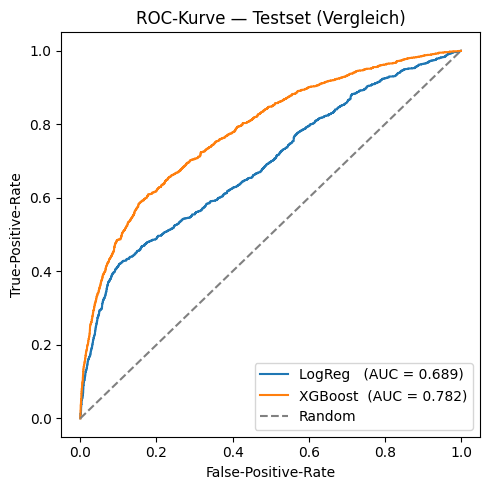

In [22]:
# ROC-Kurve für XGBoost, zusätzlich zur LogReg-Kurve zum direkten Vergleich
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_proba_xgb)

# LogReg-Kurve aus dem oberen Teil des Notebooks (best_model ist die LogReg-Pipeline)
y_proba_lr = best_model.predict_proba(X_test)[:, 1]
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_proba_lr)
test_auc_lr = roc_auc_score(y_test, y_proba_lr)

fig, ax = plt.subplots(figsize=(5, 5))
ax.plot(fpr_lr,  tpr_lr,  label=f"LogReg   (AUC = {test_auc_lr:.3f})",  color="#1f77b4")
ax.plot(fpr_xgb, tpr_xgb, label=f"XGBoost  (AUC = {test_auc_xgb:.3f})", color="#ff7f0e")
ax.plot([0, 1], [0, 1], linestyle="--", color="grey", label="Random")
ax.set_xlabel("False-Positive-Rate")
ax.set_ylabel("True-Positive-Rate")
ax.set_title("ROC-Kurve — Testset (Vergleich)")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()


## 17. Feature Importances

Analog zur Ausgabe der LogReg-Koeffizienten oben schauen wir uns bei XGBoost die
Feature Importances an. Wir verwenden den Default `importance_type="gain"` —
Summe der Gewinne aller Splits, in denen das Feature verwendet wird (typische
Wahl für „wie wichtig ist das Feature für die Vorhersage?").


In [23]:
# Feature-Namen nach Feature Engineering (Pipeline kennt die Reihenfolge)
feature_names_xgb = best_xgb[:-1].get_feature_names_out()

# Importances aus dem trainierten Booster
importances_xgb = best_xgb.named_steps["model"].feature_importances_

xgb_importance_df = (
    pd.DataFrame({"feature": feature_names_xgb, "importance": importances_xgb})
      .sort_values("importance", ascending=False)
      .reset_index(drop=True)
)

print("Top-10 Features nach Gain:")
print(xgb_importance_df.head(10))


ValueError: All arrays must be of the same length

In [ ]:
# Horizontales Balkendiagramm der Top-15 Features
top_n = 15
top = xgb_importance_df.head(top_n).iloc[::-1]   # umdrehen, damit größter Balken oben steht

fig, ax = plt.subplots(figsize=(6, 5))
ax.barh(top["feature"], top["importance"], color="#ff7f0e")
ax.set_xlabel("Importance (gain)")
ax.set_title(f"XGBoost — Top-{top_n} Feature Importances")
plt.tight_layout()
plt.show()


## 18. Default-Wahrscheinlichkeit für einen einzelnen Kunden (XGBoost)

Dieselbe Hilfsfunktion wie bei der LogReg, nur dass sie standardmäßig das
XGBoost-Modell benutzt. Als Eingabe erwartet sie ein Dict mit den Rohwerten
des Kunden (gleiche Spalten wie im Original-Datensatz, ohne `ID` und `default`).


In [ ]:
def predict_default_probability_xgb(raw_input: dict, model=best_xgb) -> float:
    """
    Wandelt einen rohen Kundendatensatz in den Feature-Vektor um, den die Pipeline
    erwartet, und gibt die Wahrscheinlichkeit eines Defaults zurück.

    Erwartete Keys in ``raw_input`` (wie im Originaldatensatz):
        LIMIT_BAL, SEX, EDUCATION, MARRIAGE, AGE,
        PAY_0, PAY_2..PAY_6, BILL_AMT1..BILL_AMT6, PAY_AMT1..PAY_AMT6
    """
    # 1) Einzeiligen DataFrame aus den Rohwerten erzeugen
    raw_df = pd.DataFrame([raw_input])

    # 2) Gleiches One-Hot-Encoding wie im Training anwenden
    raw_df = pd.get_dummies(
        raw_df,
        columns=CATEGORICAL_COLS,
        drop_first=True,
        dtype=int,
    )

    # 3) Auf exakt die Spalten / Reihenfolge der Modell-Matrix bringen
    #    (fehlende Dummy-Spalten werden mit 0 aufgefüllt)
    raw_df = raw_df.reindex(columns=MODEL_COLUMNS, fill_value=0)

    # 4) Default-Wahrscheinlichkeit zurückgeben
    proba = model.predict_proba(raw_df)[0, 1]
    return float(proba)


# Gleicher Beispielkunde wie bei der LogReg, um beide Modelle direkt vergleichen zu können
example_client = {
    "LIMIT_BAL": 50000,
    "SEX":       2,   # weiblich
    "EDUCATION": 2,   # Universität
    "MARRIAGE":  1,   # verheiratet
    "AGE":       35,
    "PAY_0": 0, "PAY_2": 0, "PAY_3": 0, "PAY_4": 0, "PAY_5": 0, "PAY_6": 0,
    "BILL_AMT1": 20000, "BILL_AMT2": 19000, "BILL_AMT3": 18000,
    "BILL_AMT4": 17000, "BILL_AMT5": 16000, "BILL_AMT6": 15000,
    "PAY_AMT1": 2000,  "PAY_AMT2": 2000, "PAY_AMT3": 2000,
    "PAY_AMT4": 2000,  "PAY_AMT5": 2000, "PAY_AMT6": 2000,
}

p_xgb = predict_default_probability_xgb(example_client)
p_lr  = predict_default_probability(example_client)  # zum Vergleich aus dem LogReg-Teil

print(f"LogReg  — Default-Wahrscheinlichkeit: {p_lr:.4f}  ({p_lr:.2%})")
print(f"XGBoost — Default-Wahrscheinlichkeit: {p_xgb:.4f}  ({p_xgb:.2%})")


### Zusammenfassung XGBoost

* Für das XGBoost-Modell haben wir die bereits vorhandene Pipeline-Infrastruktur
  wiederverwendet (Encoding, Split, Feature Engineering, `MODEL_COLUMNS`).
* **Kein Scaling** — bei baumbasierten Modellen überflüssig.
* **Class Imbalance** wird über `scale_pos_weight = #no_default / #default` behandelt.
* **Early Stopping (50 Runden)** auf einem stratifizierten 10 %-Validation-Split begrenzt
  die Anzahl der Bäume automatisch und verhindert Overfitting.
* **Hyperparameter-Tuning** mit `RandomizedSearchCV` (75 Ziehungen) über 8 Parameter
  in 5-fach stratifizierter CV, optimiert auf ROC-AUC.
* Das beste Modell wird abschließend einmal auf dem unberührten Testset evaluiert und
  direkt mit der LogReg verglichen (gemeinsamer ROC-Plot, gemeinsame Prediction-Funktion).


In [24]:
import joblib
joblib.dump(best_xgb, 'best_xgb_model.pkl')

['best_xgb_model.pkl']